# **Samuel Santiago Pinzón Reina**
# **Ingeniería de sistemas**

# Taller Heroes

In [4]:
# librerías estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import datetime

In [5]:
font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 16,
        }

In [6]:
# definir el URL de la fuente de datos
origen = 'https://paste.c-net.org/FiendGreer'

In [7]:
# cargar los datos en el dataframe
df = pd.read_csv(origen, sep=';')

In [8]:
df

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence
0,A-Bomb,Richard Milhouse Jones,"Scarsdale, Arizona",Marvel Comics,203.21,441.95,M,2008.0,Yellow,No Hair,100.0,moderate
1,Abraxas,Abraxas,Within Eternity,Marvel Comics,NaN,NaN,M,NaN,Blue,Black,100.0,high
2,Abomination,Emil Blonsky,"Zagreb, Yugoslavia",Marvel Comics,203.04,441.98,M,NaN,Green,No Hair,80.0,good
3,Adam Monroe,NaN,NaN,NBC - Heroes,NaN,NaN,M,NaN,Blue,Blond,10.0,good
4,Agent 13,Sharon Carter,NaN,Marvel Comics,173.41,61.03,F,NaN,Blue,Blond,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
730,Alan Scott,Alan Ladd Wellington Scott,Gotham City,DC Comics,180.98,90.81,M,1940.0,Blue,Blond,80.0,good
731,Amazo,NaN,NaN,DC Comics,257.49,173.95,M,1960.0,Red,NaN,100.0,good
732,Ant-Man,Hank Pym,"Elmsford, New York",Marvel Comics,211.74,122.44,M,1962.0,Blue,Blond,20.0,high
733,Ajax,Francis,NaN,Marvel Comics,193.34,90.63,M,1998.0,Brown,Black,50.0,average


In [9]:
df.head()

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence
0,A-Bomb,Richard Milhouse Jones,"Scarsdale, Arizona",Marvel Comics,203.21,441.95,M,2008.0,Yellow,No Hair,100.0,moderate
1,Abraxas,Abraxas,Within Eternity,Marvel Comics,NaN,NaN,M,NaN,Blue,Black,100.0,high
2,Abomination,Emil Blonsky,"Zagreb, Yugoslavia",Marvel Comics,203.04,441.98,M,NaN,Green,No Hair,80.0,good
3,Adam Monroe,NaN,NaN,NBC - Heroes,NaN,NaN,M,NaN,Blue,Blond,10.0,good
4,Agent 13,Sharon Carter,NaN,Marvel Comics,173.41,61.03,F,NaN,Blue,Blond,NaN,NaN


In [10]:
df.tail()

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence
730,Alan Scott,Alan Ladd Wellington Scott,Gotham City,DC Comics,180.98,90.81,M,1940.0,Blue,Blond,80.0,good
731,Amazo,NaN,NaN,DC Comics,257.49,173.95,M,1960.0,Red,NaN,100.0,good
732,Ant-Man,Hank Pym,"Elmsford, New York",Marvel Comics,211.74,122.44,M,1962.0,Blue,Blond,20.0,high
733,Ajax,Francis,NaN,Marvel Comics,193.34,90.63,M,1998.0,Brown,Black,50.0,average
734,Alex Mercer,Alexander J. Mercer,NaN,Wildstorm,NaN,NaN,M,NaN,NaN,NaN,80.0,average


In [11]:
df.shape

(735, 12)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              735 non-null    object 
 1   Identity          632 non-null    object 
 2   Birth place       317 non-null    object 
 3   Publisher         720 non-null    object 
 4   Height            518 non-null    float64
 5   Weight            498 non-null    float64
 6   Gender            706 non-null    object 
 7   First appearance  367 non-null    float64
 8   Eye color         563 non-null    object 
 9   Hair color        563 non-null    object 
 10  Strength          609 non-null    float64
 11  Intelligence      609 non-null    object 
dtypes: float64(4), object(8)
memory usage: 69.0+ KB


In [13]:
df.isnull().sum()

Name                  0
Identity            103
Birth place         418
Publisher            15
Height              217
Weight              237
Gender               29
First appearance    368
Eye color           172
Hair color          172
Strength            126
Intelligence        126
dtype: int64

In [14]:
df.Gender.unique()

array(['M', 'F', nan], dtype=object)

In [15]:
df.Gender.value_counts()

Gender
M    506
F    200
Name: count, dtype: int64

In [16]:
# indica de masa corporal
df['IMC'] = df['Weight'] / ((df['Height'] / 100) ** 2)

In [17]:
col_categoricas = ['Publisher', 'Gender', 'Eye color', 'Hair color', 'Intelligence']
col_numericas = ['Height', 'Weight', 'Strength', 'IMC']

In [18]:
for col in col_categoricas:
    print(f"{col} {df[col].unique()}")

Publisher ['Marvel Comics' 'NBC - Heroes' 'Dark Horse Comics' 'DC Comics'
 'Image Comics' 'HarperCollins' 'George Lucas' 'Shueisha' 'Team Epic TV'
 nan 'ABC Studios' 'Star Trek' 'J. R. R. Tolkien' 'Icon Comics' 'SyFy'
 'IDW Publishing' 'Sony Pictures' 'Wildstorm' 'Microsoft' 'Rebellion'
 'Titan Books' 'J. K. Rowling' 'Universal Studios' 'South Park'
 'Hanna-Barbera']
Gender ['M' 'F' nan]
Eye color ['Yellow' 'Blue' 'Green' 'Brown' nan 'Grey' 'Red' 'White' 'Black' 'Gold'
 'Violet' 'Amber' 'Hazel' 'Purple' 'brown' 'Bown' 'Yellow / Blue' 'Indigo'
 'blue' 'Yellow (without irises)' 'White / Red' 'Green / Blue'
 'Blue / White' 'Yellow / Red' 'Silver']
Hair color ['No Hair' 'Black' 'Blond' 'White' 'Brown' nan 'Strawberry Blond' 'Auburn'
 'Silver' 'Red' 'Black / Blue' 'black' 'Red / White' 'Purple' 'Orange'
 'Brown / White' 'Green' 'Grey' 'blond' 'Indigo' 'Red / Orange' 'Gold'
 'Brownn' 'Yellow' 'Blue' 'Orange / White' 'Red / Grey' 'Brown / Black'
 'Magenta' 'Pink']
Intelligence ['moderate' 'hi

In [19]:
df[col_numericas].describe()

,Height,Weight,Strength,IMC
count,518.000000,498.000000,609.000000,493.000000
mean,187.235077,112.447671,45.008210,38.687465
std,59.185250,103.964283,33.031458,133.120388
min,15.340000,2.340000,5.000000,0.098053
25%,173.935000,61.827500,10.000000,20.780687
50%,183.235000,81.750000,35.000000,24.957416
75%,190.495000,107.767500,80.000000,30.430588
max,975.370000,900.700000,100.000000,2501.321629


In [20]:
df.sort_values(by='IMC')

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
451,Groot,Groot,NaN,Marvel Comics,701.12,4.82,M,1960.0,Yellow,NaN,85.0,good,0.098053
495,Fin Fang Foom,NaN,NaN,Marvel Comics,975.37,19.00,M,NaN,Red,No Hair,85.0,average,0.199717
480,Galactus,Galan,(Galan) Taa; (Galactus) the Cosmic Egg,Marvel Comics,876.84,16.20,M,1966.0,Black,Black,100.0,high,0.210705
336,Longshot,NaN,NaN,Marvel Comics,188.23,36.71,M,1985.0,Blue,Blond,10.0,average,10.361120
100,Swarm,Fritz von Meyer,NaN,Marvel Comics,196.71,47.11,M,1977.0,Yellow,No Hair,20.0,good,12.174755
...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,Angel,Liam,NaN,Dark Horse Comics,NaN,NaN,M,NaN,NaN,NaN,30.0,good,NaN
725,Allan Quatermain,NaN,NaN,Wildstorm,NaN,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN
728,Ando Masahashi,Ando Masahashi,NaN,NBC - Heroes,NaN,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN
729,Alex Woolsly,Alex Woolsly,NaN,NBC - Heroes,NaN,NaN,M,NaN,NaN,NaN,40.0,average,NaN


In [21]:
df[ df['IMC'] > 25]

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
0,A-Bomb,Richard Milhouse Jones,"Scarsdale, Arizona",Marvel Comics,203.21,441.95,M,2008.0,Yellow,No Hair,100.0,moderate,107.024446
2,Abomination,Emil Blonsky,"Zagreb, Yugoslavia",Marvel Comics,203.04,441.98,M,NaN,Green,No Hair,80.0,good,107.211015
5,Air-Walker,Gabriel Lan,"Xandar, a planet in the Tranta system, Androme...",Marvel Comics,188.59,108.23,M,NaN,Blue,White,85.0,average,30.430588
6,Agent Bob,Bob,NaN,Marvel Comics,178.25,81.45,M,2007.0,Brown,Brown,10.0,low,25.634923
8,Abin Sur,NaN,Ungara,DC Comics,185.52,90.90,M,1959.0,Blue,No Hair,90.0,average,26.410852
...,...,...,...,...,...,...,...,...,...,...,...,...,...
722,Ammo,NaN,NaN,Marvel Comics,188.93,101.09,M,1988.0,Brown,Black,NaN,NaN,28.320854
726,Alien,Xenomorph,Your chest :),Dark Horse Comics,244.30,169.66,M,1979.0,NaN,No Hair,30.0,average,28.427098
730,Alan Scott,Alan Ladd Wellington Scott,Gotham City,DC Comics,180.98,90.81,M,1940.0,Blue,Blond,80.0,good,27.725061
731,Amazo,NaN,NaN,DC Comics,257.49,173.95,M,1960.0,Red,NaN,100.0,good,26.236367


In [22]:
df['IMC'].describe()

count     493.000000
mean       38.687465
std       133.120388
min         0.098053
25%        20.780687
50%        24.957416
75%        30.430588
max      2501.321629
Name: IMC, dtype: float64

<Axes: >

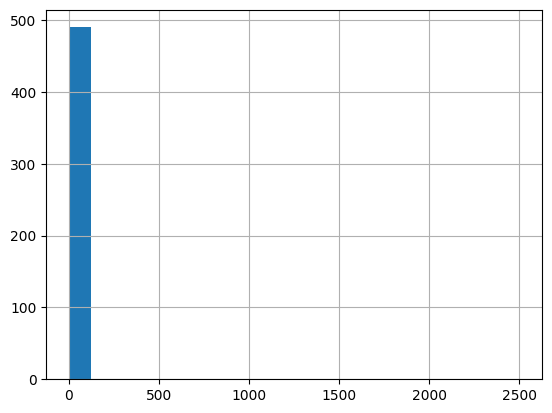

In [23]:
df['IMC'].hist(bins=20)

In [24]:
for col in col_numericas:
  df[col].fillna(0.0, inplace=True)

C:\Users\famil\AppData\Local\Temp\ipykernel_12976\2429413965.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(0.0, inplace=True)


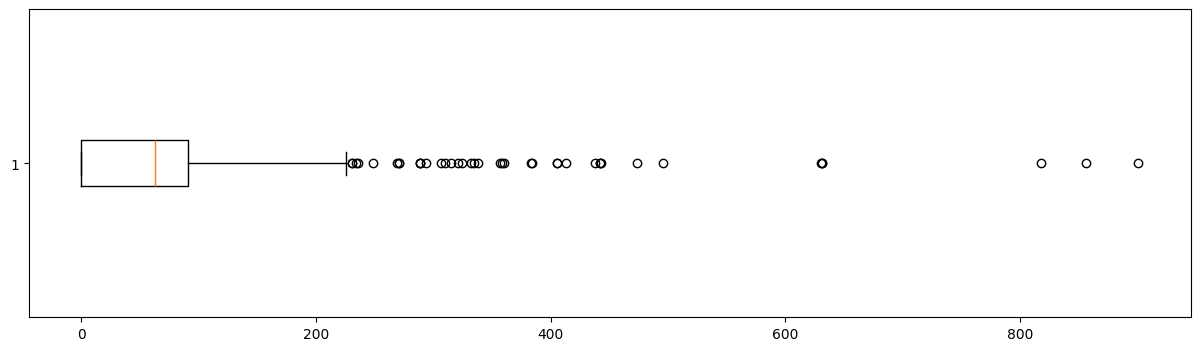

In [25]:
fig = plt.figure(figsize =(15, 4))
plt.boxplot(df['Weight'], vert=False)
plt.show()

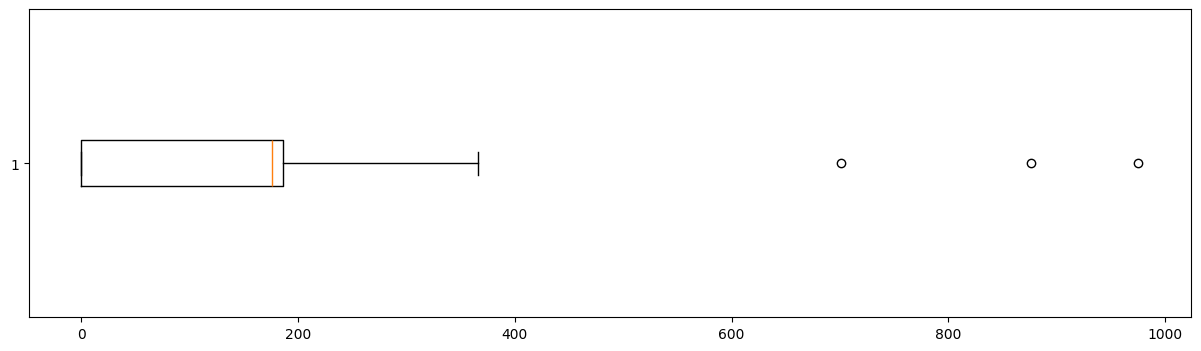

In [26]:
fig = plt.figure(figsize =(15, 4))
plt.boxplot(df['Height'], vert=False)
plt.show()

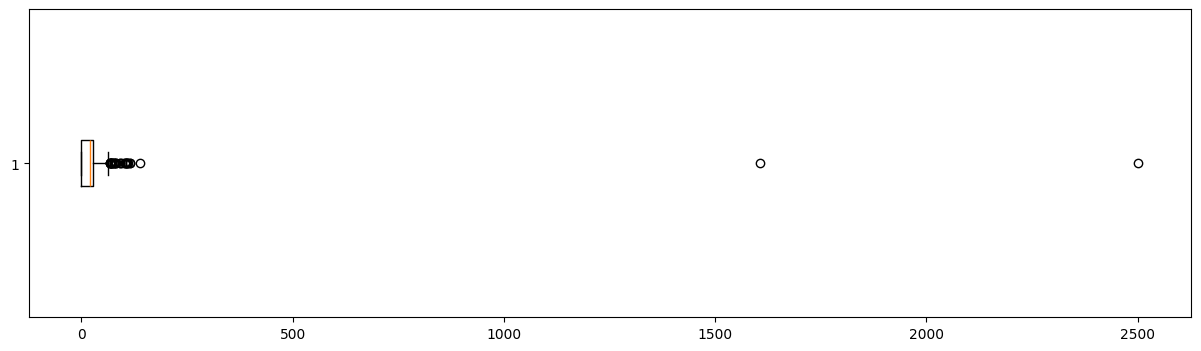

In [27]:
fig = plt.figure(figsize =(15, 4))
plt.boxplot(df['IMC'], vert=False)
plt.show()

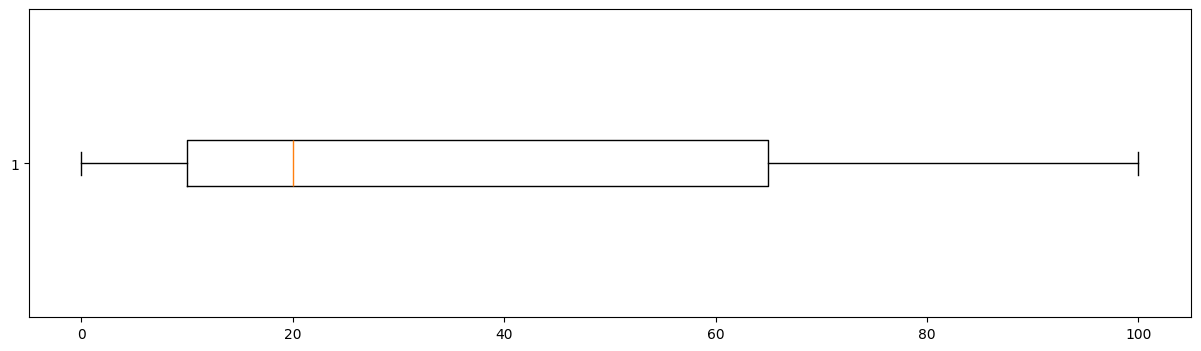

In [28]:
fig = plt.figure(figsize =(15, 4))
plt.boxplot(df['Strength'], vert=False)
plt.show()

<Axes: xlabel='Height', ylabel='Gender'>

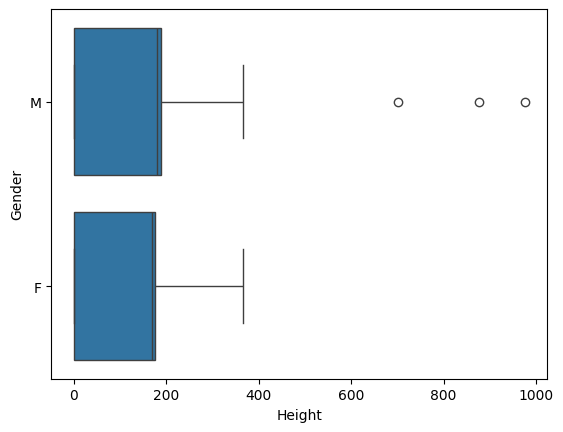

In [29]:
sns.boxplot(x="Height", y="Gender", data=df)

<Axes: xlabel='Strength', ylabel='Gender'>

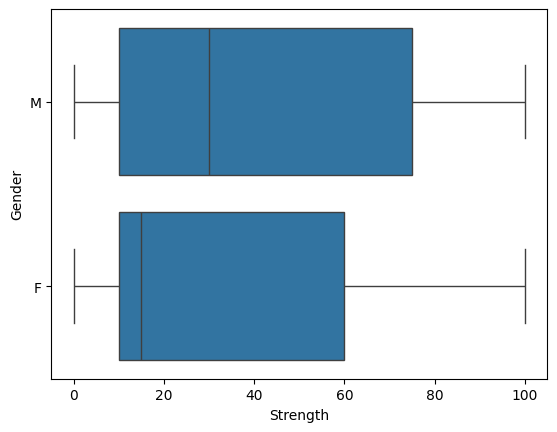

In [30]:
sns.boxplot(x="Strength", y="Gender", data=df)

In [31]:
dfp = df.groupby(['Publisher']).count().reset_index()[['Publisher','Name']]
dfp.columns = ['Publisher','Count']
dfp

,Publisher,Count
0,ABC Studios,4
1,DC Comics,216
2,Dark Horse Comics,18
3,George Lucas,14
4,Hanna-Barbera,1
5,HarperCollins,6
6,IDW Publishing,4
7,Icon Comics,4
8,Image Comics,14
9,J. K. Rowling,1


<Axes: ylabel='Count'>

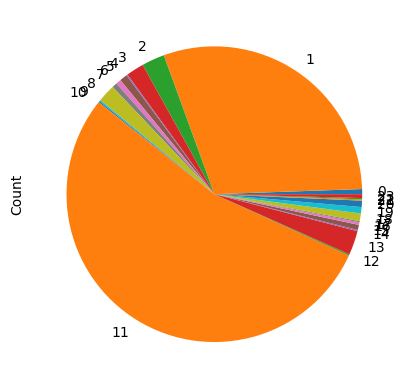

In [32]:
dfp['Count'].plot.pie()

In [33]:
dfp.columns

Index(['Publisher', 'Count'], dtype='object')

In [34]:
dfp.loc[  dfp.Count < 10, 'Publisher'] = 'Other'

In [35]:
dfp

,Publisher,Count
0,Other,4
1,DC Comics,216
2,Dark Horse Comics,18
3,George Lucas,14
4,Other,1
5,Other,6
6,Other,4
7,Other,4
8,Image Comics,14
9,Other,1


In [36]:
dfp2 = dfp.groupby(['Publisher']).sum().reset_index()

In [37]:
dfp2

,Publisher,Count
0,DC Comics,216
1,Dark Horse Comics,18
2,George Lucas,14
3,Image Comics,14
4,Marvel Comics,388
5,NBC - Heroes,19
6,Other,51


<Axes: ylabel='Count'>

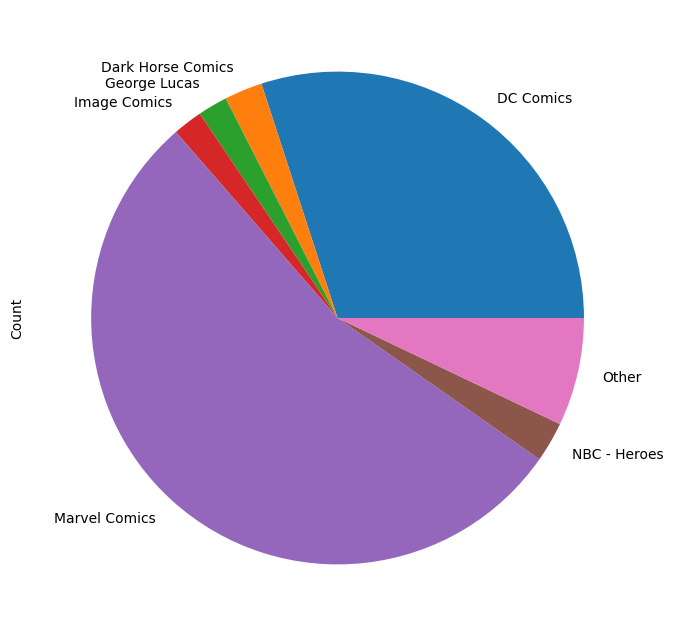

In [38]:
dfp2.plot.pie(y='Count', labels=dfp2['Publisher'], figsize=(8,8), legend=False)

# Cómo es la Fuerza con respecto al Género?

<Axes: xlabel='Gender', ylabel='count'>

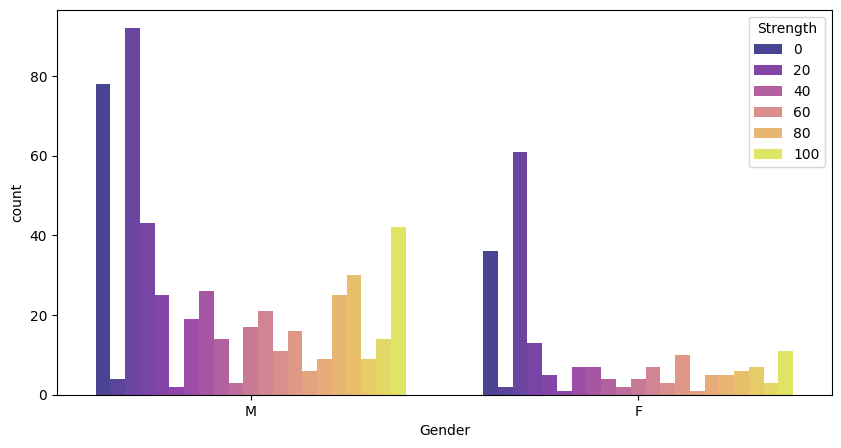

In [39]:
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = df, x = "Gender", hue = "Strength", palette = "plasma", alpha = 0.8)

In [40]:
# Cómo es la Fuerza con respecto al Género
df.groupby("Gender")["Strength"].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,200.0,32.150000,32.997297,0.0,10.0,15.0,60.0,100.0
M,506.0,39.525692,34.652052,0.0,10.0,30.0,75.0,100.0


**R/** Como podemos ver, la fuerza es bastante similar, ya que tienen unos cuartiles y una desvación estándar bastante parecidas. Pero si vemos la media, veremos que los heroes masculinos son un poco más fuertes que las heroínas.
Y esto lo podemos ver reflejado en el gráfico, ya que hay muy pocas heroínas con una fuerza por encima de 60

# Cómo es la Inteligencia con respecto al Género??

In [41]:
# Agrupar Inteligencia por género, y contar
df.groupby("Gender")["Intelligence"].describe()

,count,unique,top,freq
Gender,,,,
F,164,4,good,78
M,428,5,good,165


<Axes: xlabel='Gender', ylabel='count'>

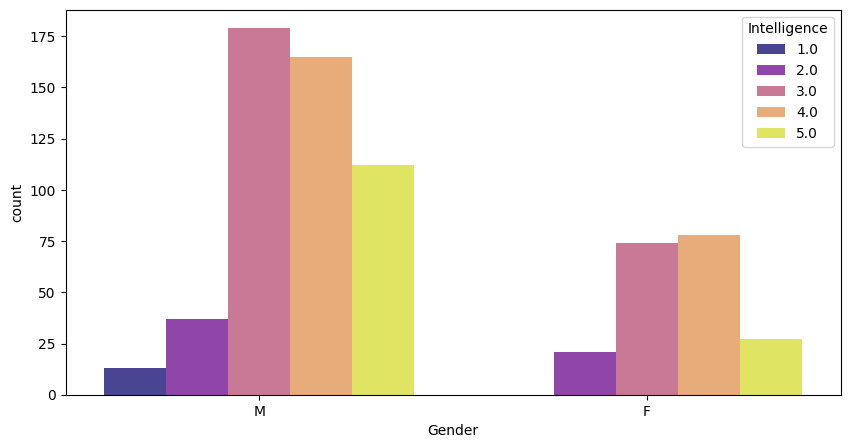

In [71]:
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(data = df, x = "Gender", hue = "Intelligence", palette = "plasma", alpha = 0.8)

**R/** Como podemos ver no hay mucha diferencia entre las inteligencias de ambos generos, la principal diferencia que hay es ocasionada por la falta de datos de mujeres, pero si vemos, ambas graficas tienen una distribución bastante similar.

# Cuáles son los 10 heroes más fuertes?

In [43]:
# Heroes más fuertes (cualquier género)
df.sort_values(by = "Strength", ascending = False)[:10].reset_index()

,index,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
0,0,A-Bomb,Richard Milhouse Jones,"Scarsdale, Arizona",Marvel Comics,203.21,441.95,M,2008.0,Yellow,No Hair,100.0,moderate,107.024446
1,455,Granny Goodness,NaN,Apokolips,DC Comics,178.22,115.84,F,NaN,Blue,White,100.0,high,36.470832
2,362,King Kong,King Kong,Skull Island,NaN,30.87,9.79,M,1933.0,Yellow,Black,100.0,average,102.732873
3,90,Thanos,Thanos,Titan,Marvel Comics,201.26,443.19,M,NaN,Red,No Hair,100.0,high,109.414534
4,1,Abraxas,Abraxas,Within Eternity,Marvel Comics,0.00,0.00,M,NaN,Blue,Black,100.0,high,0.000000
5,377,Juggernaut,Cain Marko,"Berkeley, California",Marvel Comics,287.95,855.82,M,1965.0,Blue,Red,100.0,average,103.216295
6,412,Hyperion,Mark Milton,NaN,Marvel Comics,183.82,207.29,M,NaN,Blue,Red,100.0,high,61.346929
7,425,Hulk,Bruce Banner,"Dayton, Ohio",Marvel Comics,244.40,630.90,M,1962.0,Green,Green,100.0,high,105.622909
8,428,Hela,NaN,NaN,Marvel Comics,213.50,225.81,F,NaN,Green,Black,100.0,good,49.539020
9,434,Hercules,Heracles,"Thebes, Greece",Marvel Comics,196.14,146.76,M,NaN,Blue,Brown,100.0,good,38.148315


**R/** Los 10 heroes más fuertes son:
1. A-Bomb
2. Granny Goodness
3. King Kong
4. Thanos
5. Abraxas
6. Juggernaut
7. Hyperion
8. Hulk
9. Hela
10. Hercules

# Cuáles son los 10 heroes (hombres) más débiles en 'DC Comics'?

In [44]:
#Separación por heroes unicamente de DC Comics
dc_df = df[ df.Publisher == "DC Comics" ]
dc_df

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
8,Abin Sur,NaN,Ungara,DC Comics,185.52,90.90,M,1959.0,Blue,No Hair,90.0,average,26.410852
10,Animal Man,Bernhard Baker,NaN,DC Comics,183.80,83.39,M,1965.0,Blue,Blond,50.0,average,24.684422
15,Zoom,Hunter Zolomon,NaN,DC Comics,185.90,81.93,M,NaN,Red,Brown,10.0,average,23.707414
18,Zatanna,Zatanna Zatara,NaN,DC Comics,170.29,57.77,F,NaN,Blue,Black,10.0,high,19.921594
26,Adam Strange,Adam Strange,"Chicago, Illinois",DC Comics,185.10,88.92,M,1986.0,Blue,Blond,10.0,good,25.952943
...,...,...,...,...,...,...,...,...,...,...,...,...,...
714,Aquaman,Orin,Atlantis,DC Comics,185.71,146.96,M,1941.0,Blue,Blond,85.0,high,42.611671
716,Anti-Monitor,NaN,Moon of Qward,DC Comics,61.37,0.00,M,NaN,Yellow,No Hair,100.0,high,0.000000
727,Alfred Pennyworth,Alfred Thaddeus Crane Pennyworth,NaN,DC Comics,178.26,72.98,M,1943.0,Blue,Black,10.0,good,22.966566
730,Alan Scott,Alan Ladd Wellington Scott,Gotham City,DC Comics,180.98,90.81,M,1940.0,Blue,Blond,80.0,good,27.725061


In [45]:
#Creamos y aplicamos el filtro para solo tener los heroes hombres
filtro = dc_df["Gender"] == "M"
dc_df = dc_df[filtro]

In [46]:
#Ya que solo tenemos los heroes masculinos de DC los organizamos por su fuerza
dc_df.drop_duplicates(subset = "Name", inplace = True)
dc_df.sort_values(by = "Strength", ascending = True)[:10].reset_index(drop = True)

C:\Users\famil\AppData\Local\Temp\ipykernel_12976\2203365460.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dc_df.drop_duplicates(subset = "Name", inplace = True)


,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
0,Plastic Lad,Luke O'Brian,NaN,DC Comics,0.0,0.00,M,NaN,NaN,NaN,0.0,NaN,0.0
1,Speedy,"Roy William Harper, Jr.",NaN,DC Comics,0.0,0.00,M,NaN,NaN,NaN,0.0,NaN,0.0
2,Atom,NaN,NaN,DC Comics,0.0,0.00,M,NaN,NaN,NaN,0.0,NaN,0.0
3,Mogo,Mogo,NaN,DC Comics,0.0,0.00,M,1985.0,NaN,NaN,0.0,NaN,0.0
4,Atom IV,Ryan Choi,NaN,DC Comics,0.0,72.07,M,NaN,Brown,Black,0.0,NaN,0.0
5,Atom III,Adam Cray,NaN,DC Comics,0.0,0.00,M,NaN,NaN,Red,0.0,NaN,0.0
6,Nite Owl II,Daniel Dreiberg,NaN,DC Comics,0.0,0.00,M,NaN,NaN,NaN,0.0,NaN,0.0
7,ERG-1,NaN,NaN,DC Comics,0.0,0.00,M,NaN,NaN,NaN,0.0,NaN,0.0
8,Moloch,Edgar William Jacobi,NaN,DC Comics,0.0,0.00,M,NaN,NaN,NaN,0.0,NaN,0.0
9,Arsenal,"Roy William Harper, Jr.",NaN,DC Comics,0.0,0.00,M,NaN,NaN,NaN,0.0,NaN,0.0


**R/** Los diez heroes más débiles de DC Comics son:
1. Trickster
2. ERG-1
3. Atom
4. Mogo
5. Atom III
6. Atom IV
7. Nite Owl II
8. Moloch
9. Arsenal
10. Blue Beetle

# Cuáles son los 10 heroes más inteligentes?

In [47]:
#Buscamos los distintos tipos de inteligencia que hay en la columna de inteligencia
df.Intelligence.unique()

array(['moderate', 'high', 'good', nan, 'average', 'low'], dtype=object)

In [48]:
#Para conocer los heroes más inteligentes debemos de pasar de una variable categorica a una ordinal, ya que nos permite conocer en una escala de 1 a 5 (de menor a mayor) clasificar la inteligencia. Y de paso llenamos los valores nulos con 3, que representa una inteligencia promedio.
df["Intelligence"].replace({"high": 5, "good": 4, "average": 3, "moderate":2, "low": 1, np.nan: 3}, inplace = True)

C:\Users\famil\AppData\Local\Temp\ipykernel_12976\295275777.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Intelligence"].replace({"high": 5, "good": 4, "average": 3, "moderate":2, "low": 1, np.nan: 3}, inplace = True)
C:\Users\famil\AppData\Local\Temp\ipykernel_12976\295275777.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('

In [49]:
#Ordenamos por inteligencia y mostramos los 10 más inteligentes
df.sort_values(by = "Intelligence", ascending = False)[:10].reset_index(drop = True)

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
0,Beast,Henry Philip McCoy,"Dunfee, Illinois",Marvel Comics,180.85,181.73,M,NaN,Blue,Blue,50.0,5.0,55.563501
1,Steppenwolf,NaN,NaN,DC Comics,183.36,91.04,M,NaN,Red,Black,100.0,5.0,27.078403
2,Hyperion,Mark Milton,NaN,Marvel Comics,183.82,207.29,M,NaN,Blue,Red,100.0,5.0,61.346929
3,Mandarin,Khan,China,Marvel Comics,188.10,97.65,M,1964.0,Blue,White,30.0,5.0,27.599083
4,Magus,NaN,Kvch (Technarchy�s home planet),Marvel Comics,183.74,0.00,M,1984.0,Black,NaN,100.0,5.0,0.000000
5,Red Robin,Tim Drake,Gotham City,DC Comics,165.39,56.35,M,1989.0,Blue,Black,15.0,5.0,20.600389
6,Bane,NaN,NaN,DC Comics,203.22,180.48,M,1993.0,NaN,NaN,40.0,5.0,43.701484
7,Superman,Clark Kent,Krypton,DC Comics,191.73,101.73,M,NaN,Blue,Black,100.0,5.0,27.673807
8,Stardust,NaN,NaN,Marvel Comics,0.00,0.00,M,NaN,NaN,NaN,85.0,5.0,0.000000
9,Martian Manhunter,J'onn J'onzz,NaN,DC Comics,201.86,135.18,M,1955.0,Red,No Hair,95.0,5.0,33.175074


**R/** Los 10 heroes más inteligentes son:
1. Beast
2. Steppenwolf
3. Hyperion
4. Mandarin
5. Magus
6. Red Robin
7. Bane
8. Superman
9. Stardust
10. Martian Manhunter

# Cuáles son los 10 heroinas más inteligentes en 'Marvel Comics'?


In [50]:
# Heroinas más inteligentes, solo 'Marvel Comics'
#Separamos en un dataframe aparte a heroes unicamente de Marvel Comics
marvel_df = df[ df.Publisher == "Marvel Comics" ]
marvel_df

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
0,A-Bomb,Richard Milhouse Jones,"Scarsdale, Arizona",Marvel Comics,203.21,441.95,M,2008.0,Yellow,No Hair,100.0,2.0,107.024446
1,Abraxas,Abraxas,Within Eternity,Marvel Comics,0.00,0.00,M,NaN,Blue,Black,100.0,5.0,0.000000
2,Abomination,Emil Blonsky,"Zagreb, Yugoslavia",Marvel Comics,203.04,441.98,M,NaN,Green,No Hair,80.0,4.0,107.211015
4,Agent 13,Sharon Carter,NaN,Marvel Comics,173.41,61.03,F,NaN,Blue,Blond,0.0,3.0,20.295282
5,Air-Walker,Gabriel Lan,"Xandar, a planet in the Tranta system, Androme...",Marvel Comics,188.59,108.23,M,NaN,Blue,White,85.0,3.0,30.430588
...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,Angel,Warren Kenneth Worthington III,"Centerport, Long Island, New York",Marvel Comics,183.05,68.99,M,1969.0,Blue,Blond,15.0,4.0,20.589542
722,Ammo,NaN,NaN,Marvel Comics,188.93,101.09,M,1988.0,Brown,Black,0.0,3.0,28.320854
723,Arachne,Julia Carpenter,"Los Angeles, California",Marvel Comics,175.15,63.75,F,NaN,Blue,Blond,50.0,3.0,20.780687
732,Ant-Man,Hank Pym,"Elmsford, New York",Marvel Comics,211.74,122.44,M,1962.0,Blue,Blond,20.0,5.0,27.309736


In [51]:
filtro_genero = marvel_df[ "Gender"] == "F"
marvel_df = marvel_df[filtro_genero]

In [52]:
marvel_df.sort_values(by = "Intelligence", ascending = False)[:10].reset_index(drop = True)

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
0,Shadowcat,Kitty Pryde,"Deerfield, Illinois",Marvel Comics,168.63,50.40,F,1980.0,Hazel,Brown,10.0,5.0,17.723964
1,Valkyrie,Brunnhilde (also spelled Brunnhilda),Presumably Asgard,Marvel Comics,191.63,214.67,F,NaN,Blue,Blond,95.0,5.0,58.458054
2,Jean Grey,Jean Grey,NaN,Marvel Comics,168.53,52.68,F,1963.0,Green,Red,80.0,5.0,18.547754
3,Lady Bullseye,NaN,NaN,Marvel Comics,0.00,0.00,F,NaN,NaN,Black,75.0,5.0,0.000000
4,Phoenix,Jean Grey,NaN,Marvel Comics,168.89,52.07,F,1963.0,Green,Red,100.0,5.0,18.254910
5,She-Hulk,Jennifer Walters,"Los Angeles, California",Marvel Comics,201.68,315.26,F,NaN,Green,Green,100.0,5.0,77.507407
6,Scarlet Witch,Wanda Maximoff,"Wundagore Mountain, Transia",Marvel Comics,170.18,59.69,F,1964.0,Blue,Brown,10.0,5.0,20.610311
7,Cat,Shirlee Bryant,"Chicago, Illinois",Marvel Comics,173.65,61.58,F,NaN,Blue,Blond,90.0,5.0,20.421616
8,Captain Marvel,Carol Danvers,"Boston, Massachusetts",Marvel Comics,180.92,74.23,F,NaN,Blue,Blond,90.0,5.0,22.678081
9,Invisible Woman,Susan Storm Richards,"Glenville, Long Island, New York",Marvel Comics,168.33,54.92,F,NaN,blue,Blond,10.0,5.0,19.382397


**R/** Las heroínas de Marvel más inteligentes son:
1.   Shadowcat
2. Valkyrie
3. Jean Grey
4. Lady Bullseye
5. Phoenix
5. She-Hulk
6. Scarlet Witch
8. Cat
9. Captain Marvel
10. Invisible Woman

# Quién tiene más heroes con fuerza mayor a 90, DC o Marvel?

In [53]:
#Creamos nuevamente el dataframe que contenga solo a heroes de Marvel Comics y DC Comics
marvel_df = df[ df.Publisher == "Marvel Comics"]

dc_df = df[ df.Publisher == "DC Comics" ]

In [54]:
#Hacemos el conteo de heroes con fuerza mayor a 90

print(f"Número de heroes de Marvel Comics con fuerza mayor a 90: {len(marvel_df[ marvel_df.Strength > 90 ])}")

print(f"El número de heroes de DC Comics con fuerza mayor a 90 es de: {len(dc_df[ dc_df.Strength > 90 ])}")

Número de heroes de Marvel Comics con fuerza mayor a 90: 31
El número de heroes de DC Comics con fuerza mayor a 90 es de: 35


In [55]:
#Si queremos ver los heroes de Marvel ejecutamos esta línea
marvel_df[ marvel_df.Strength > 90 ].reset_index(drop = True).head()

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
0,A-Bomb,Richard Milhouse Jones,"Scarsdale, Arizona",Marvel Comics,203.21,441.95,M,2008.0,Yellow,No Hair,100.0,2.0,107.024446
1,Abraxas,Abraxas,Within Eternity,Marvel Comics,0.00,0.00,M,NaN,Blue,Black,100.0,5.0,0.000000
2,Ymir,Ymir,Niffleheim,Marvel Comics,304.63,0.00,M,NaN,White,No Hair,100.0,3.0,0.000000
3,Wonder Man,Simon Williams,"Paterson, New Jersey",Marvel Comics,188.90,171.57,M,NaN,Red,Black,100.0,4.0,48.081437
4,Valkyrie,Brunnhilde (also spelled Brunnhilda),Presumably Asgard,Marvel Comics,191.63,214.67,F,NaN,Blue,Blond,95.0,5.0,58.458054


In [56]:
#Si queremos ver los heroes de DC Comics8888 ejecutamos esta línea
dc_df[ dc_df.Strength > 90 ].reset_index(drop = True).head()

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
0,Wonder Woman,Diana Prince,Themyscira,DC Comics,183.13,74.74,F,1941.0,Blue,Black,100.0,5.0,22.286101
1,Trigon,NaN,NaN,DC Comics,0.00,0.00,M,1981.0,Yellow,Black,100.0,5.0,0.000000
2,Swamp Thing,Alec Holland,NaN,DC Comics,0.00,0.00,M,1972.0,Red,No Hair,95.0,5.0,0.000000
3,Supergirl,Kara Zor-El,"Argo City, Krypton",DC Comics,165.40,54.80,F,2004.0,Blue,Blond,100.0,5.0,20.031319
4,Superboy-Prime,Kal-El,Krypton (Earth-Prime),DC Comics,180.55,77.41,M,1985.0,Blue,Black / Blue,100.0,5.0,23.746635


**R/** DC Comics es la empresa con mayor número de heroes con una fuerza mayor a 90, ya que cuenta con 35 personajes distintos que tienen más de 90 puntos de fuerza.

# Basados en el IMC, cuántos heroes hay en cada categoría?

| Categoría | IMC |
|:---------:|:---:|
|Peso inferior al normal|menor a 18.5|
|Normal|18.5 - 24.9|
|Peso superior al normal|25.0 – 29.9|
|Obesidad|mayor a 30.0|

In [57]:
#Creamos función para que evalue el IMC y lo ponga en una de las cuatro categorías
def categorizar_imc(imc):
    if imc < 18.5:
        return 'Peso inferior al normal'
    elif 18.5 <= imc <= 24.9:
        return 'Normal'
    elif 25.0 <= imc <= 29.9:
        return 'Peso superior al normal'
    else:
        return 'Obesidad'

In [58]:
# Se aplica la función a la columna de IMC
df['IMC'] = df['IMC'].apply(categorizar_imc)

In [59]:
df["IMC"].value_counts()

IMC
Peso inferior al normal    283
Normal                     201
Obesidad                   137
Peso superior al normal    114
Name: count, dtype: int64

**R/** Basados en el IMC de cada heroe y las distintas categorias, tenemos la siguiente cantidad de heroes:

|Categoría  | Cantidad de heroes|
|----|:--:|
|Peso inferior al normal|283|
|Normal|201|
|Peso superior al normal|114|
|Obesidad| 137|

# Cómo se distribuye la creación de heroes a traves del tiempo?

In [60]:
#Creamos el dataframe años, en él guardaremos el año en el que se crearon los heroes, y haremos un conteo sobre la cantidad de apariciones por año
años = pd.DataFrame(df["First appearance"].value_counts())

#Ordenamos por año
años.sort_values(by = "First appearance", inplace = True)

#El índice de First appearance ahora lo volvemos columna
años.reset_index(inplace = True)
años

,First appearance,count
0,1933.0,1
1,1939.0,1
2,1940.0,9
3,1941.0,7
4,1943.0,2
...,...,...
66,2012.0,2
67,2013.0,1
68,2015.0,2
69,2016.0,2


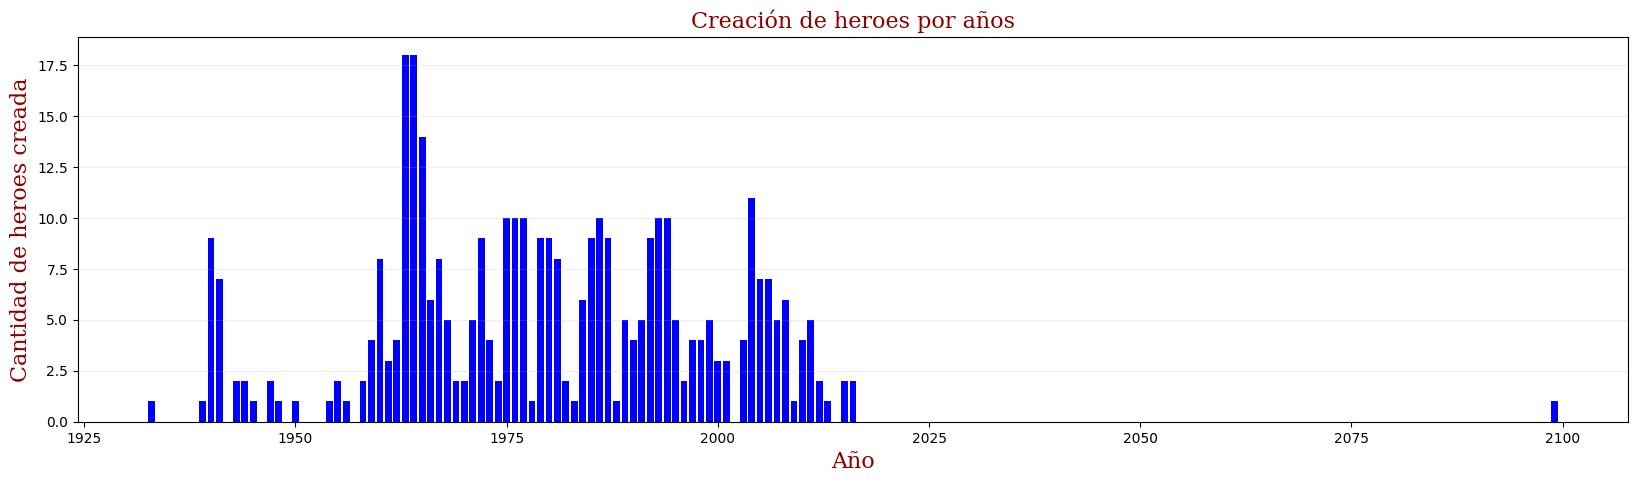

In [61]:
# Gráfico con x="año" ordenado, y="heroes creados en ese año"
plt.figure(figsize = (20,5))

plt.bar(x = años["First appearance"], height = años["count"], color = "b")

plt.grid(axis = "y", alpha = 0.2)
plt.title("Creación de heroes por años", font)
plt.xlabel("Año", font)
plt.ylabel("Cantidad de heroes creada", font)
plt.show()

**R/** Como podemos ver, la creación de los heroes ha estado siempre bastante activa, podemos ver que hubo un boom en la creación de los mismos a partir de los años 60's, en donde alcanzó su auge y de ahí en adelante ha tenido varias caídas, la más notoria es la de los años 2000's ya que ha estado constantemente cayendo y no se ha recuperado.

Escriba **5 Preguntas adicionales diferentes a las anteriores** y respondalas:

---


# Pregunta 1 ¿Cuáles son los heroes más altos?

In [62]:
# Heroes más altos
df.sort_values(by = "Height", ascending = False)[:10].reset_index(drop = True)

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
0,Fin Fang Foom,NaN,NaN,Marvel Comics,975.37,19.00,M,NaN,Red,No Hair,85.0,3.0,Peso inferior al normal
1,Galactus,Galan,(Galan) Taa; (Galactus) the Cosmic Egg,Marvel Comics,876.84,16.20,M,1966.0,Black,Black,100.0,5.0,Peso inferior al normal
2,Groot,Groot,NaN,Marvel Comics,701.12,4.82,M,1960.0,Yellow,NaN,85.0,4.0,Peso inferior al normal
3,Wolfsbane,Rahne Sinclair,"Somewhere in Ross and Cromarty, Scotland",Marvel Comics,366.34,473.76,F,NaN,Green,Auburn,20.0,2.0,Obesidad
4,MODOK,George Tarleton,NaN,Marvel Comics,366.20,338.21,M,NaN,White,Brownn,20.0,5.0,Peso superior al normal
5,Onslaught,Onslaught,NaN,Marvel Comics,305.41,405.08,M,1996.0,Red,No Hair,100.0,5.0,Obesidad
6,Sasquatch,Walter Langkowski,"Edmonton, Alberta, Canada",Marvel Comics,305.02,900.70,M,NaN,Red,Orange,80.0,4.0,Obesidad
7,Ymir,Ymir,Niffleheim,Marvel Comics,304.63,0.00,M,NaN,White,No Hair,100.0,3.0,Peso inferior al normal
8,Rey,NaN,Jakku,George Lucas,297.12,0.00,F,2015.0,Hazel,Brown,10.0,4.0,Peso inferior al normal
9,Juggernaut,Cain Marko,"Berkeley, California",Marvel Comics,287.95,855.82,M,1965.0,Blue,Red,100.0,3.0,Obesidad


**R/** Los heroes más altos son:
1. Fin Fang Foom
2. Galactus
3. Groot
4. Wolfsbane
5. MODOK
6. Onslaught
7. Sasquatch
8. Ymir
9. Rey
10. Juggernaut


# Pregunta 2 ¿Quiénes son los heroes más antiguos que se han publicado?

In [63]:
df.sort_values(by = "First appearance", ascending = True)[:10].reset_index(drop = True)

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
0,King Kong,King Kong,Skull Island,NaN,30.87,9.79,M,1933.0,Yellow,Black,100.0,3.0,Obesidad
1,Namor,Namor McKenzie,Atlantis,Marvel Comics,188.39,125.24,M,1939.0,Grey,Black,95.0,4.0,Obesidad
2,Hawkman,Carter Hall,NaN,DC Comics,185.32,88.54,M,1940.0,Blue,Brown,65.0,4.0,Peso superior al normal
3,Flash,Jay Garrick,"Hibbardsville, Kansas",DC Comics,180.86,81.07,M,1940.0,Blue,Brown / White,10.0,4.0,Normal
4,Robin,Dick Grayson,NaN,DC Comics,178.21,79.49,M,1940.0,Blue,Black,15.0,5.0,Peso superior al normal
5,Joker,Jack Napier,NaN,DC Comics,196.07,86.91,M,1940.0,Green,Green,10.0,5.0,Normal
6,Alan Scott,Alan Ladd Wellington Scott,Gotham City,DC Comics,180.98,90.81,M,1940.0,Blue,Blond,80.0,4.0,Peso superior al normal
7,Aztar,Aztar,NaN,DC Comics,0.00,0.00,M,1940.0,NaN,NaN,100.0,5.0,Peso inferior al normal
8,Doctor Fate,Kent Nelson,NaN,DC Comics,188.81,89.45,M,1940.0,Blue,Blond,20.0,5.0,Peso superior al normal
9,Shazam,Billy Batson,"Fawcett City, United States",DC Comics,193.74,101.30,M,1940.0,Blue,Black,100.0,5.0,Peso superior al normal


**R/** Los 10 heroes más antiguos de esta lista son:
1. King Kong 🦍
2. Namor
3. Hawkman
4. Flash
5. Robin
6. Joker
7. Alan Scott
8. Aztar
9. Doctor Fate
10. Shazam

# Pregunta 3 ¿Cuál es el promedio de peso según el genero?

In [64]:
#Creamos la variable para almacenar el promedio del peso. Pero primero agruparemos los datos según el genero
promedio_peso = df.groupby('Gender')['Weight'].mean()
promedio_peso

Gender
F    56.353000
M    84.646403
Name: Weight, dtype: float64

**R/** El peso promedio de las heroínas es de: 56.353 kg

Y el peso primedio de los heroes es de: 84.646 kg

# Pregunta 4 ¿Cuánta fuerza tienen los heroés más inteligentes?

In [65]:
#Creamos un nuevo dataframe en el cual solo tengamos heroes con un nivel de inteligencia mayor a 4
df_inteligencia = df[df.Intelligence >= 4]
df_inteligencia.head()

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
1,Abraxas,Abraxas,Within Eternity,Marvel Comics,0.00,0.00,M,NaN,Blue,Black,100.0,5.0,Peso inferior al normal
2,Abomination,Emil Blonsky,"Zagreb, Yugoslavia",Marvel Comics,203.04,441.98,M,NaN,Green,No Hair,80.0,4.0,Obesidad
3,Adam Monroe,NaN,NaN,NBC - Heroes,0.00,0.00,M,NaN,Blue,Blond,10.0,4.0,Peso inferior al normal
7,Abe Sapien,Abraham Sapien,NaN,Dark Horse Comics,191.24,65.35,M,1993.0,Blue,No Hair,30.0,5.0,Peso inferior al normal
9,Angela,NaN,NaN,Image Comics,0.00,0.00,F,NaN,NaN,NaN,100.0,5.0,Peso inferior al normal


In [66]:
#Para calcular la fuerza promedio de los heroes sacamos la media
df_inteligencia['Strength'].mean()

47.87723785166241

In [67]:
#Para saber el promedio de fuerza más especificamente por el genero de los heroes
df_inteligencia.groupby('Gender')['Strength'].mean()

Gender
F    44.666667
M    48.519856
Name: Strength, dtype: float64

**R/** En los heroes con una inteligencia de 4 o 5 puntos, podemos ver que tienen una inteligencia promedio de 47.88 puntos. Pero siendo más especificos, las heroínas más inteligentes tienen una fuerza promedio de 44.67 puntos, estando por debajo de los heroes masculinos que tienen un promedio de edad de 48.52 puntos.
Con lo que podemos concluir que los heroes más inteligentes no son los más fuertes.

# Pregunta 5 ¿Cuáles son los heroes o personajes más fuertes que no pertenezcan ni a DC Comics ni Marvel?

In [68]:
#Hacemos el filtro para excluir los personajes de Marvel y DC Comics de la columna Publisher
df_no = df[~df["Publisher"].isin(["Marvel Comics", "DC Comics"])]

In [69]:
#Visualización de los datos
df_no.head()

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
3,Adam Monroe,NaN,NaN,NBC - Heroes,0.00,0.00,M,NaN,Blue,Blond,10.0,4.0,Peso inferior al normal
7,Abe Sapien,Abraham Sapien,NaN,Dark Horse Comics,191.24,65.35,M,1993.0,Blue,No Hair,30.0,5.0,Peso inferior al normal
9,Angela,NaN,NaN,Image Comics,0.00,0.00,F,NaN,NaN,NaN,100.0,5.0,Peso inferior al normal
12,Colin Wagner,NaN,NaN,HarperCollins,0.00,0.00,M,NaN,Grey,Brown,0.0,3.0,Peso inferior al normal
17,Yoda,Yoda,NaN,George Lucas,66.29,17.01,M,1980.0,Brown,White,55.0,5.0,Obesidad


In [70]:
#Ordenamos por fuerza
df_no.sort_values(by = "Strength", ascending = False)[:10].reset_index(drop = True)

,Name,Identity,Birth place,Publisher,Height,Weight,Gender,First appearance,Eye color,Hair color,Strength,Intelligence,IMC
0,Angela,NaN,NaN,Image Comics,0.00,0.00,F,NaN,NaN,NaN,100.0,5.0,Peso inferior al normal
1,Goku,Kakarot,NaN,Shueisha,175.49,62.02,M,NaN,NaN,NaN,100.0,3.0,Normal
2,Godzilla,Gojira,NaN,NaN,108.55,90.93,NaN,1954.0,NaN,NaN,100.0,3.0,Obesidad
3,One Punch Man,Saitama,NaN,Shueisha,175.64,69.95,M,NaN,NaN,No Hair,100.0,2.0,Normal
4,Vegeta,Vegeta,NaN,Shueisha,168.94,73.24,M,NaN,NaN,Black,100.0,5.0,Peso superior al normal
5,Cy-Gor,NaN,NaN,Image Comics,0.00,0.00,M,NaN,NaN,NaN,100.0,3.0,Peso inferior al normal
6,King Kong,King Kong,Skull Island,NaN,30.87,9.79,M,1933.0,Yellow,Black,100.0,3.0,Obesidad
7,Man of Miracles,NaN,NaN,Image Comics,0.00,0.00,NaN,NaN,Blue,Silver,100.0,5.0,Peso inferior al normal
8,Astro Boy,Atom,NaN,NaN,0.00,0.00,M,NaN,Brown,Black,95.0,3.0,Peso inferior al normal
9,Hancock,John Hancock,NaN,Sony Pictures,188.90,0.00,M,NaN,Brown,Black,90.0,4.0,Peso inferior al normal


**R/** Los heroes más fuertes que no sean ni de DC Comics ni Marvel son:
1. Angela
2. Goku
3. Godzilla 🦎
4. Saitama
5. Vegeta
6. Cy-Gor
7. King Kong 🦍
8. Man of Miracles
9. Astro Boy
10. Hancock